# Crypto Price Prediction — v9

**Modeling baseline notebook**

**v9 (simplified):** Compact baseline pipeline. Two baselines (last value, 7-day MA); **Ridge** (30 return lags + log_volume + volatility_14, Optuna-tuned); **LSTM** (64→32 units, dropout, early stopping). **4-group ablation** (lags → +volume → +volatility → all). **Interpretability** (permutation importance + PDP/ICE on Ridge). **Error analysis** (residuals + where model fails). **Expanding-window** evaluation (Ridge). No XGBoost/ensemble/stacking/classifier.

Set `ASSET` below and **Runtime → Run all**.


In [1]:
# ── CONFIG ────────────────────────────────────────────────────────────
ASSET = "ETC-USD"          # Change to BTC-USD, ETH-USD, XRP-USD, etc.
N_LAGS = 30                # Number of return lags
SEQ_LEN = 30               # LSTM sequence length
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15            # test = 1 - train - val = 0.15
RANDOM_STATE = 42

In [2]:
# Pin numpy/pandas for Colab + TensorFlow compatibility
!pip install -q "numpy>=1.26,<2.2" "pandas>=2.2.3,<3"
!pip install -q yfinance pyarrow scikit-learn tensorflow matplotlib seaborn optuna
print("Install done. Ignore other pip conflict warnings for this notebook.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 13.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.3 MB/s eta 0:00:00
Install done. Ignore other pip conflict warnings for this notebook.


**Colab:** If you see `ValueError: numpy.dtype size changed` or `ImportError: cannot load module more than once per process`, use **Runtime → Restart session**, then run from the top. Only run the fix cell below if the dtype error persists; then restart again and run from the top (skip the fix cell next time).

In [3]:
# Fix numpy/pandas (run only if you saw "numpy.dtype size changed"). Then Restart session and re-run from top.
# !pip install --force-reinstall --no-cache-dir "numpy>=1.26,<2.2" "pandas>=2.2.3,<3" -q
print("If you uncommented and ran the line above: Runtime → Restart session, then run all from top (skip this cell next time).")

If you uncommented and ran the line above: Runtime → Restart session, then run all from top (skip this cell next time).


In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import tensorflow as tf
from tensorflow.keras import layers, callbacks

print(f"NumPy {np.__version__}, Pandas {pd.__version__}, TF {tf.__version__}")


NumPy 2.0.2, Pandas 2.3.3, TF 2.19.0


## 1. Data Loading

In [5]:
# Download main asset
raw = yf.download(ASSET, start="2017-01-01", end=None, progress=False, auto_adjust=True)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.droplevel(1)
raw.index = pd.to_datetime(raw.index).tz_localize(None)
raw = raw.sort_index().ffill().dropna()

print(f"{ASSET}: {len(raw)} rows, {raw.index[0].date()} to {raw.index[-1].date()}")


ETC-USD: 3036 rows, 2017-11-09 to 2026-03-03


## 2. Feature Engineering (v9: minimal)

30 return lags + **log_volume**, **volatility_14** (32 features). Ablation adds these incrementally (Section 9).


In [6]:
# Base features (v9: lags + volume + volatility only)
df = pd.DataFrame(index=raw.index)
df["price"] = raw["Close"].values
df["volume"] = raw["Volume"].values.astype(float)
df["volume"] = df["volume"].fillna(0)

df["ret"] = (df["price"] - df["price"].shift(1)) / (df["price"].shift(1) + 1e-12)
df["log_volume"] = np.log1p(df["volume"])
df["volatility_14"] = df["ret"].rolling(14).std()

df = df.iloc[30:].copy()
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

EXTRA_FEATURE_COLS = ["log_volume", "volatility_14"]
LSTM_FEATURE_COLS = ["ret", "log_volume", "volatility_14"]

print(f"DataFrame shape: {df.shape}")
print(f"Total features for Ridge: {N_LAGS} lags + {len(EXTRA_FEATURE_COLS)} = {N_LAGS + len(EXTRA_FEATURE_COLS)}")
print(f"LSTM features per timestep: {len(LSTM_FEATURE_COLS)}")


DataFrame shape: (3006, 5)
Total features for Ridge: 30 lags + 2 = 32
LSTM features per timestep: 3


In [7]:
# ── Time-based split ──────────────────────────────────────────
n = len(df)
train_end = int(TRAIN_FRAC * n)
val_end = int((TRAIN_FRAC + VAL_FRAC) * n)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Train: {len(train_df)} rows ({train_df.index[0].date()} to {train_df.index[-1].date()})")
print(f"Val:   {len(val_df)} rows ({val_df.index[0].date()} to {val_df.index[-1].date()})")
print(f"Test:  {len(test_df)} rows ({test_df.index[0].date()} to {test_df.index[-1].date()})")

Train: 2104 rows (2017-12-09 to 2023-09-12)
Val:   451 rows (2023-09-13 to 2024-12-06)
Test:  451 rows (2024-12-07 to 2026-03-03)


In [8]:
# ── Metrics ───────────────────────────────────────────────────
def regression_metrics(y_true, y_pred):
    """MAE, RMSE, directional accuracy (price-level)."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    if len(y_true) > 1:
        true_dir = np.sign(np.diff(y_true))
        pred_dir = np.sign(y_pred[1:] - y_true[:-1])
        dir_acc = np.mean(true_dir == pred_dir)
    else:
        dir_acc = np.nan
    return {"mae": float(mae), "rmse": float(rmse), "dir_acc": float(dir_acc)}

def dir_acc_returns(y_true, y_pred):
    """Directional accuracy on returns (sign match)."""
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    valid = np.abs(y_true) > 1e-10
    if valid.sum() == 0:
        return 0.0
    return float(np.mean(np.sign(y_true[valid]) == np.sign(y_pred[valid])))

def metrics_from_returns(y_true_ret, y_pred_ret, prev_prices=None):
    """Return-level metrics + optional price-level metrics."""
    da = dir_acc_returns(y_true_ret, y_pred_ret)
    mae_ret = float(np.mean(np.abs(np.asarray(y_true_ret) - np.asarray(y_pred_ret))))
    rmse_ret = float(np.sqrt(np.mean((np.asarray(y_true_ret) - np.asarray(y_pred_ret)) ** 2)))
    result = {"mae_ret": mae_ret, "rmse_ret": rmse_ret, "dir_acc": da}
    if prev_prices is not None:
        y_true_price = np.asarray(prev_prices) * (1 + np.asarray(y_true_ret))
        y_pred_price = np.asarray(prev_prices) * (1 + np.asarray(y_pred_ret))
        result["mae_price"] = float(np.mean(np.abs(y_true_price - y_pred_price)))
        result["rmse_price"] = float(np.sqrt(np.mean((y_true_price - y_pred_price) ** 2)))
    return result

print("Metrics functions defined.")

Metrics functions defined.


## 3. Baselines

In [9]:
# ── Baselines on test set (price-level) ──────────────────────
test_prices = test_df["price"].values

# Last value: predict tomorrow = today
pred_last = test_prices[:-1]
y_test_price = test_prices[1:]
m_last = regression_metrics(y_test_price, pred_last)

# 7-day MA
ma7 = pd.Series(test_prices).rolling(7).mean().values
pred_ma = ma7[:-1]
valid_ma = ~np.isnan(pred_ma)
m_ma = regression_metrics(y_test_price[valid_ma], pred_ma[valid_ma])

print("=== Baselines (test set, price-level) ===")
print(f"Last value:  MAE={m_last['mae']:.4f}, RMSE={m_last['rmse']:.4f}, Dir.Acc={m_last['dir_acc']:.4f}")
print(f"7-day MA:    MAE={m_ma['mae']:.4f}, RMSE={m_ma['rmse']:.4f}, Dir.Acc={m_ma['dir_acc']:.4f}")

=== Baselines (test set, price-level) ===
Last value:  MAE=0.5563, RMSE=0.8465, Dir.Acc=0.0000
7-day MA:    MAE=0.8490, RMSE=1.2289, Dir.Acc=0.5530


## 4. Lag Feature Construction (Return-based)

In [10]:
# ── Build return lags + extra features for Ridge ─────
def build_return_lag_matrix(df_slice, n_lags, extra_cols):
    """Build feature matrix: n_lags return lags + extra columns.
    Target: next-day return."""
    ret = df_slice["ret"].values
    T = len(ret)
    rows_X, rows_y, rows_extra, rows_pp = [], [], [], []
    extra_vals = df_slice[extra_cols].values
    prices = df_slice["price"].values

    for t in range(n_lags, T - 1):
        lag_features = [ret[t - lag] for lag in range(1, n_lags + 1)]
        rows_X.append(lag_features)
        rows_extra.append(extra_vals[t])
        rows_y.append(ret[t + 1])        # next-day return
        rows_pp.append(prices[t])

    X_lags = np.array(rows_X, dtype=np.float64)
    X_extra = np.array(rows_extra, dtype=np.float64)
    X = np.hstack([X_lags, X_extra])
    y = np.array(rows_y, dtype=np.float64)
    prev_prices = np.array(rows_pp, dtype=np.float64)
    return X, y, prev_prices

X_train, y_train, pp_train = build_return_lag_matrix(train_df, N_LAGS, EXTRA_FEATURE_COLS)
X_val, y_val, pp_val = build_return_lag_matrix(val_df, N_LAGS, EXTRA_FEATURE_COLS)
X_test, y_test, pp_test = build_return_lag_matrix(test_df, N_LAGS, EXTRA_FEATURE_COLS)

FEATURE_NAMES = [f"lag_{i}" for i in range(1, N_LAGS + 1)] + EXTRA_FEATURE_COLS

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")
print(f"Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES[:5]} ... {FEATURE_NAMES[-5:]}")


X_train: (2073, 32), y_train: (2073,)
X_val:   (420, 32),   y_val:   (420,)
X_test:  (420, 32),  y_test:  (420,)
Features (32): ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5'] ... ['lag_28', 'lag_29', 'lag_30', 'log_volume', 'volatility_14']


## 5. Ridge Regression (Return Lags + Volume, Volatility)


In [11]:
# ── Ridge with Optuna (Assessment §4c: efficient hyperparameter search) ──
n_f = X_train.shape[1]
tscv = TimeSeriesSplit(n_splits=5, gap=21)

def ridge_objective(trial):
    alpha = trial.suggest_float("ridge__alpha", 1e-2, 1e2, log=True)
    pipe = Pipeline([
        ("scale", ColumnTransformer(
            [("s", StandardScaler(), list(range(n_f)))],
            remainder="passthrough"
        )),
        ("ridge", Ridge(alpha=alpha)),
    ])
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_va = X_train[train_idx], X_train[val_idx]
        y_tr, y_va = y_train[train_idx], y_train[val_idx]
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_va)
        scores.append(-np.mean(np.abs(y_va - pred)))
    return np.mean(scores)

study_ridge = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, n_startup_trials=10))
study_ridge.optimize(ridge_objective, n_trials=30, show_progress_bar=False)
best_alpha = study_ridge.best_params["ridge__alpha"]

best_ridge = Pipeline([
    ("scale", ColumnTransformer(
        [("s", StandardScaler(), list(range(n_f)))],
        remainder="passthrough"
    )),
    ("ridge", Ridge(alpha=best_alpha)),
])
best_ridge.fit(X_train, y_train)
# For ablation/compat, expose best_params as if from RandomizedSearchCV
search_ridge = type('Search', (), {'best_params_': {'ridge__alpha': best_alpha}, 'best_estimator_': best_ridge})()

print(f"Best Ridge alpha (Optuna): {best_alpha:.4f}")

# Predictions
pred_ridge_train = best_ridge.predict(X_train)
pred_ridge_val = best_ridge.predict(X_val)
pred_ridge_test = best_ridge.predict(X_test)

m_ridge = metrics_from_returns(y_test, pred_ridge_test, pp_test)
print(f"Ridge test: MAE_ret={m_ridge['mae_ret']:.6f}, Dir.Acc={m_ridge['dir_acc']:.4f}, MAE_price={m_ridge.get('mae_price', 0):.4f}")

Best Ridge alpha (Optuna): 99.2744
Ridge test: MAE_ret=0.030073, Dir.Acc=0.4976, MAE_price=0.5287


## 6. LSTM
Sequences: 30 steps, 3 features (ret, log_volume, volatility_14). 64→32 units, dropout 0.2, early stopping, ReduceLROnPlateau.


In [12]:
# ── Build LSTM sequences ─────────────────────────────────────
# §4d: No data leakage — last training sequence uses features up to last row of df_slice;
# target is next-day return ending at that last row (so we never use future/val data).
def build_lstm_sequences(df_slice, seq_len, feature_cols):
    """Build (n_samples, seq_len, n_features) sequences. Target = next-day return.
    Last sample uses rows [T-seq_len-1 .. T-2], predicts ret[T-1] (last row of slice)."""
    vals = df_slice[feature_cols].values.astype(np.float32)
    ret = df_slice["ret"].values.astype(np.float32)
    prices = df_slice["price"].values.astype(np.float64)
    T = len(vals)

    X_list, y_list, pp_list = [], [], []
    for t in range(seq_len, T - 1):
        X_list.append(vals[t - seq_len : t])
        y_list.append(ret[t + 1])
        pp_list.append(prices[t])

    return np.array(X_list), np.array(y_list), np.array(pp_list)

X_tr_lstm, y_tr_lstm, pp_tr_lstm = build_lstm_sequences(train_df, SEQ_LEN, LSTM_FEATURE_COLS)
X_va_lstm, y_va_lstm, pp_va_lstm = build_lstm_sequences(val_df, SEQ_LEN, LSTM_FEATURE_COLS)
X_te_lstm, y_te_lstm, pp_te_lstm = build_lstm_sequences(test_df, SEQ_LEN, LSTM_FEATURE_COLS)

print(f"LSTM X_train: {X_tr_lstm.shape}, y_train: {y_tr_lstm.shape}")
print(f"LSTM X_val:   {X_va_lstm.shape}")
print(f"LSTM X_test:  {X_te_lstm.shape}")

LSTM X_train: (2073, 30, 3), y_train: (2073,)
LSTM X_val:   (420, 30, 3)
LSTM X_test:  (420, 30, 3)


In [13]:
# ── Scale LSTM sequences (fit on train only) ────────────────
n_tr, sl, nf = X_tr_lstm.shape
lstm_scaler = StandardScaler()
lstm_scaler.fit(X_tr_lstm.reshape(-1, nf))

X_tr_sc = lstm_scaler.transform(X_tr_lstm.reshape(-1, nf)).reshape(n_tr, sl, nf).astype(np.float32)
X_va_sc = lstm_scaler.transform(X_va_lstm.reshape(-1, nf)).reshape(X_va_lstm.shape[0], sl, nf).astype(np.float32)
X_te_sc = lstm_scaler.transform(X_te_lstm.reshape(-1, nf)).reshape(X_te_lstm.shape[0], sl, nf).astype(np.float32)

print("LSTM sequences scaled (train statistics only).")

LSTM sequences scaled (train statistics only).


In [14]:
# ── LSTM model ───────────────────────────────────────────────
tf.random.set_seed(RANDOM_STATE)

model_lstm = tf.keras.Sequential([
    layers.Input(shape=(SEQ_LEN, len(LSTM_FEATURE_COLS))),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(1),
])

model_lstm.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_lstm.summary()

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

# Train
history = model_lstm.fit(
    X_tr_sc, y_tr_lstm,
    validation_data=(X_va_sc, y_va_lstm),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0,
)

n_epochs = len(history.history["loss"])
print(f"\nLSTM trained for {n_epochs} epochs (early stopping).")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 22: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 27: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 12.

LSTM trained for 27 epochs (early stopping).


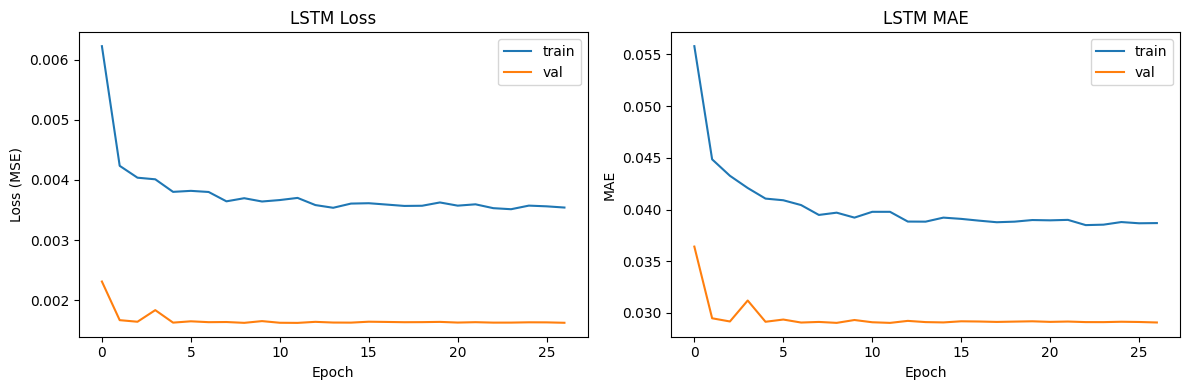

In [15]:
# ── LSTM training curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss (MSE)")
axes[0].legend(); axes[0].set_title("LSTM Loss")

axes[1].plot(history.history["mae"], label="train")
axes[1].plot(history.history["val_mae"], label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE")
axes[1].legend(); axes[1].set_title("LSTM MAE")
plt.tight_layout()
plt.show()

In [16]:
# ── LSTM predictions & metrics ───────────────────────────────
pred_lstm_val = model_lstm.predict(X_va_sc, verbose=0).ravel()
pred_lstm_test = model_lstm.predict(X_te_sc, verbose=0).ravel()

m_lstm = metrics_from_returns(y_te_lstm, pred_lstm_test, pp_te_lstm)
print(f"LSTM test: MAE_ret={m_lstm['mae_ret']:.6f}, Dir.Acc={m_lstm['dir_acc']:.4f}, MAE_price={m_lstm.get('mae_price', 0):.4f}")

LSTM test: MAE_ret=0.029928, Dir.Acc=0.4500, MAE_price=0.5277


## 7. Full Comparison Table


In [17]:
# Comparison table (v9: baselines + Ridge + LSTM)
da_ridge_test = dir_acc_returns(y_test, pred_ridge_test)
da_lstm_test = dir_acc_returns(y_te_lstm, pred_lstm_test)

rows = [
    ["Last Value", f"{m_last['mae']:.4f}", f"{m_last['rmse']:.4f}", f"{m_last['dir_acc']:.4f}", "—"],
    ["7-day MA", f"{m_ma['mae']:.4f}", f"{m_ma['rmse']:.4f}", f"{m_ma['dir_acc']:.4f}", "—"],
    ["Ridge (v9)", f"{m_ridge.get('mae_price', 0):.4f}", f"{m_ridge.get('rmse_price', 0):.4f}", f"{da_ridge_test:.4f}", f"{m_ridge['mae_ret']:.6f}"],
    ["LSTM (v9)", f"{m_lstm.get('mae_price', 0):.4f}", f"{m_lstm.get('rmse_price', 0):.4f}", f"{da_lstm_test:.4f}", f"{m_lstm['mae_ret']:.6f}"],
]
comp_df = pd.DataFrame(rows, columns=["Model", "MAE (price)", "RMSE (price)", "Dir.Acc", "MAE (return)"])
print("\n" + "=" * 80)
print(f"COMPARISON TABLE — {ASSET} (v9)")
print("=" * 80)
print(comp_df.to_string(index=False))
print("=" * 80)



COMPARISON TABLE — ETC-USD (v9)
     Model MAE (price) RMSE (price) Dir.Acc MAE (return)
Last Value      0.5563       0.8465  0.0000            —
  7-day MA      0.8490       1.2289  0.5530            —
Ridge (v9)      0.5287       0.7696  0.4976     0.030073
 LSTM (v9)      0.5277       0.7734  0.4500     0.029928


In [ ]:
# Bar graph: directional accuracy of all models
models_acc = ["Last Value", "7-day MA", "Ridge", "LSTM"]
dir_acc_pct = [
    m_last["dir_acc"] * 100,
    m_ma["dir_acc"] * 100,
    da_ridge_test * 100,
    da_lstm_test * 100,
]
colors = ["gray", "steelblue", "darkorange", "green"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models_acc, dir_acc_pct, color=colors, edgecolor="black", linewidth=0.8)
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="Random (50%)")
ax.set_ylabel("Directional accuracy (%)")
ax.set_xlabel("Model")
ax.set_title(f"Directional accuracy by model — {ASSET} (v9)")
ax.set_ylim(0, 100)
ax.legend()
for bar, val in zip(bars, dir_acc_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f"{val:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 8. Expanding-Window Evaluation

Walk-forward: retrain Ridge on expanding train; report mean ± std of MAE (return) and Dir.Acc.


In [18]:
# Expanding-window: Ridge only (v9)
N_WINDOWS = 5
n_test = len(test_df)
if n_test < N_WINDOWS * 20:
    N_WINDOWS = max(2, n_test // 30)
chunk_ends = np.linspace(0, n_test, N_WINDOWS + 1, dtype=int)

dir_acc_ridge_w, mae_ret_ridge_w = [], []
for w in range(N_WINDOWS):
    start_w, end_w = chunk_ends[w], chunk_ends[w + 1]
    if end_w - start_w < 5:
        continue
    train_end_w = val_end + start_w
    train_df_w = df.iloc[:train_end_w].copy()
    test_df_w = test_df.iloc[start_w:end_w].copy()
    X_tr_w, y_tr_w, _ = build_return_lag_matrix(train_df_w, N_LAGS, EXTRA_FEATURE_COLS)
    X_te_w, y_te_w, _ = build_return_lag_matrix(test_df_w, N_LAGS, EXTRA_FEATURE_COLS)
    if len(X_te_w) == 0:
        continue
    scaler_w = StandardScaler()
    X_tr_sc_w = scaler_w.fit_transform(X_tr_w)
    X_te_sc_w = scaler_w.transform(X_te_w)
    ridge_w = Ridge(alpha=best_alpha).fit(X_tr_sc_w, y_tr_w)
    pr_ridge_w = ridge_w.predict(X_te_sc_w)
    dir_acc_ridge_w.append(dir_acc_returns(y_te_w, pr_ridge_w))
    mae_ret_ridge_w.append(np.mean(np.abs(np.asarray(y_te_w) - pr_ridge_w)))

dir_acc_ridge_w = np.array(dir_acc_ridge_w)
mae_ret_ridge_w = np.array(mae_ret_ridge_w)
print("=== Expanding-Window Evaluation (Ridge) ===\n")
print(f"Ridge — Dir.Acc: {dir_acc_ridge_w.mean():.4f} ± {dir_acc_ridge_w.std():.4f},  MAE_ret: {mae_ret_ridge_w.mean():.6f} ± {mae_ret_ridge_w.std():.6f}")
print(f"(Across {len(dir_acc_ridge_w)} test windows)")


=== Expanding-Window Evaluation (Ridge) ===

Ridge — Dir.Acc: 0.5067 ± 0.0515,  MAE_ret: 0.032262 ± 0.003639
(Across 5 test windows)


## 9. Ablation Study (4 groups)

(1) Lags only, (2) + volume, (3) + volatility, (4) all.


In [19]:
# Ridge ablation: 4 feature groups (v9)
def fit_ridge_subset(X_tr, y_tr, X_te, y_te, pp_te, alpha):
    n = X_tr.shape[1]
    pipe = Pipeline([
        ("scale", ColumnTransformer([("s", StandardScaler(), list(range(n)))], remainder="passthrough")),
        ("ridge", Ridge(alpha=alpha)),
    ])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    return metrics_from_returns(y_te, pred, pp_te), dir_acc_returns(y_te, pred)

best_alpha = search_ridge.best_params_["ridge__alpha"]
extra_idx = {name: N_LAGS + i for i, name in enumerate(EXTRA_FEATURE_COLS)}
def cols_for(extra_names):
    return list(range(N_LAGS)) + [extra_idx[n] for n in extra_names]

g1_extra = []
g2_extra = ["log_volume"]
g3_extra = ["volatility_14"]
g4_extra = ["log_volume", "volatility_14"]
idx1, idx2, idx3, idx4 = cols_for(g1_extra), cols_for(g2_extra), cols_for(g3_extra), cols_for(g4_extra)

m_abl1, da_abl1 = fit_ridge_subset(X_train[:, idx1], y_train, X_test[:, idx1], y_test, pp_test, best_alpha)
m_abl2, da_abl2 = fit_ridge_subset(X_train[:, idx2], y_train, X_test[:, idx2], y_test, pp_test, best_alpha)
m_abl3, da_abl3 = fit_ridge_subset(X_train[:, idx3], y_train, X_test[:, idx3], y_test, pp_test, best_alpha)
m_abl4, da_abl4 = fit_ridge_subset(X_train[:, idx4], y_train, X_test[:, idx4], y_test, pp_test, best_alpha)

abl_rows = [
    [f"Lags only ({len(idx1)})", f"{m_abl1['mae_ret']:.6f}", f"{da_abl1:.4f}"],
    [f"+ volume ({len(idx2)})", f"{m_abl2['mae_ret']:.6f}", f"{da_abl2:.4f}"],
    [f"+ volatility ({len(idx3)})", f"{m_abl3['mae_ret']:.6f}", f"{da_abl3:.4f}"],
    [f"All ({len(idx4)})", f"{m_abl4['mae_ret']:.6f}", f"{da_abl4:.4f}"],
]
abl_df = pd.DataFrame(abl_rows, columns=["Features", "MAE (return)", "Dir.Acc"])
print("\n=== Ridge Ablation (4 groups) ===")
print(abl_df.to_string(index=False))



=== Ridge Ablation (4 groups) ===
         Features MAE (return) Dir.Acc
   Lags only (30)     0.030125  0.5071
    + volume (31)     0.030031  0.5000
+ volatility (31)     0.030115  0.5095
         All (32)     0.030073  0.4976


## 10. Interpretability

Permutation importance + PDP/ICE for **Ridge** (rubric).


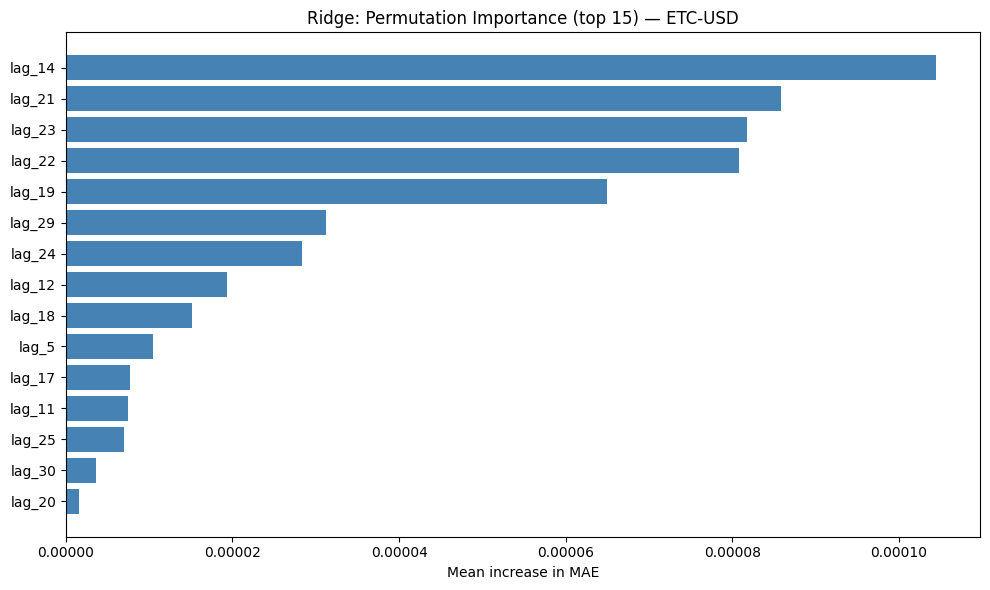


Ridge top 3: ['lag_14', 'lag_21', 'lag_23']


In [20]:
# Permutation importance (Ridge only, v9)
perm = permutation_importance(best_ridge, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring="neg_mean_absolute_error")
perm_imp = perm.importances_mean
top_k = min(15, len(FEATURE_NAMES))
top_idx_perm = np.argsort(perm_imp)[-top_k:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_idx_perm)), perm_imp[top_idx_perm], color="steelblue")
plt.yticks(range(len(top_idx_perm)), [FEATURE_NAMES[i] for i in top_idx_perm])
plt.xlabel("Mean increase in MAE")
plt.title(f"Ridge: Permutation Importance (top {top_k}) — {ASSET}")
plt.tight_layout()
plt.show()
top3_ridge = [FEATURE_NAMES[i] for i in np.argsort(perm_imp)[-3:][::-1]]
print(f"\nRidge top 3: {top3_ridge}")


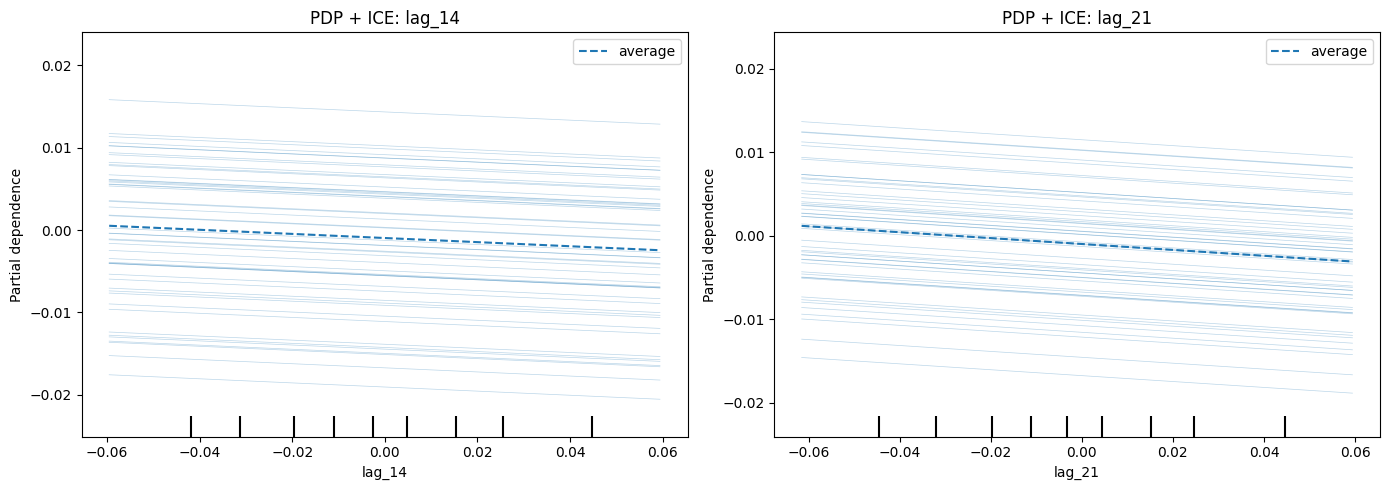

In [21]:
# ── PDP for top 2 features (Ridge) ───────────────────────────
top2_features = [np.argsort(perm_imp)[-1], np.argsort(perm_imp)[-2]]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat_idx in zip(axes, top2_features):
    PartialDependenceDisplay.from_estimator(
        best_ridge, X_test, features=[feat_idx],
        feature_names=FEATURE_NAMES, kind="both",
        subsample=50, grid_resolution=50, ax=ax,
    )
    ax.set_title(f"PDP + ICE: {FEATURE_NAMES[feat_idx]}")
plt.tight_layout()
plt.show()

## 11. Error Analysis

Residual plots and where the model performs poorly (rubric).


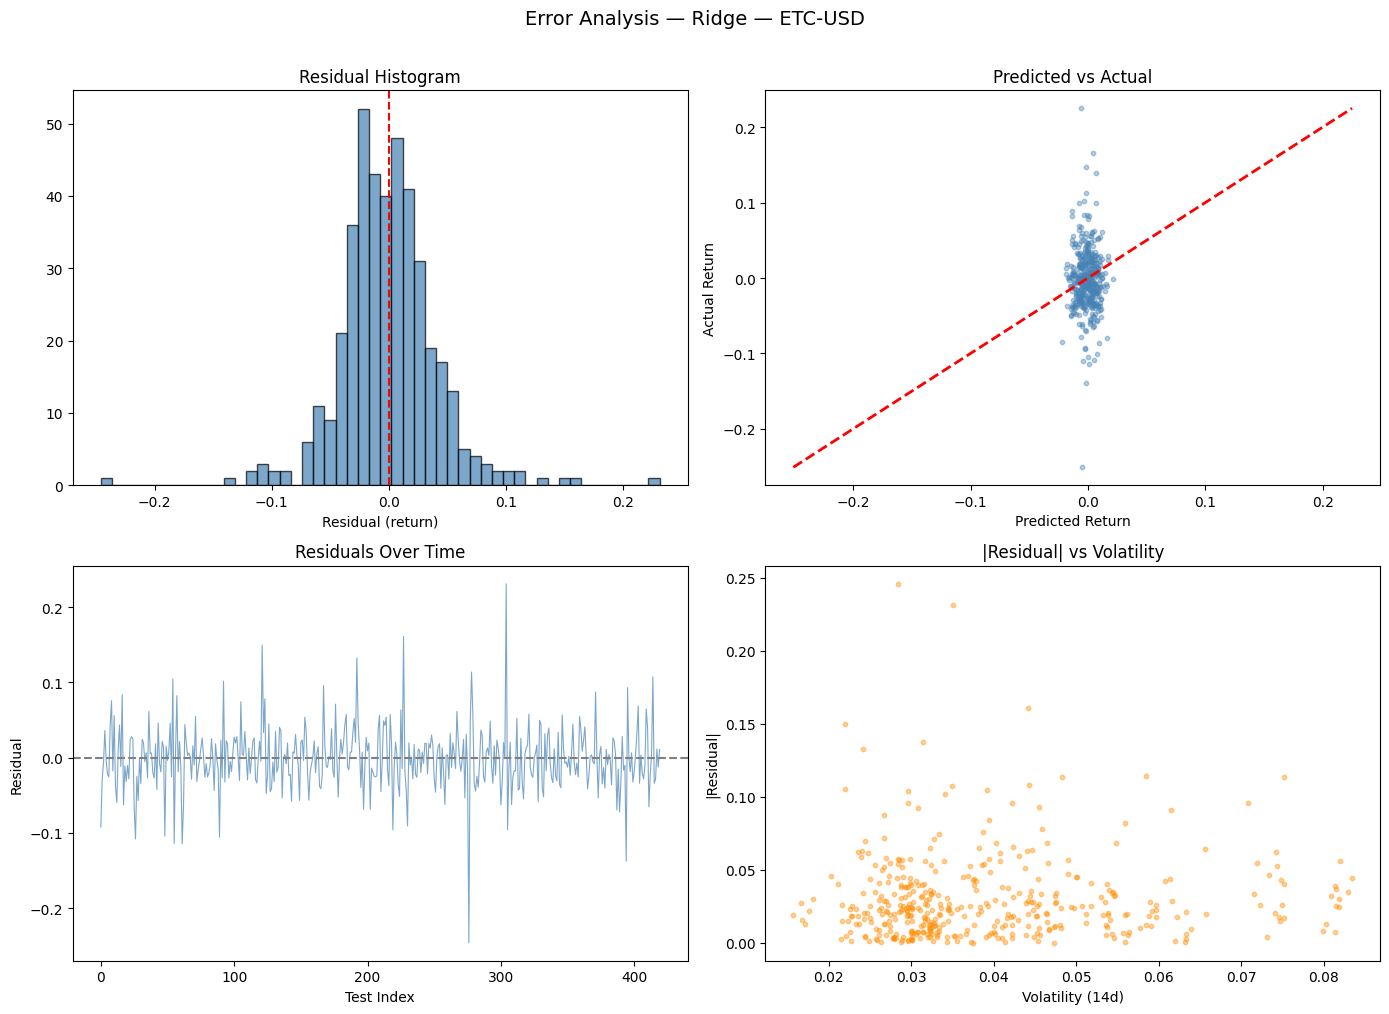


Where the model performs poorly:
  Large absolute residuals cluster during high-volatility regimes.
  The model under/overpredicts sharp moves (tail events).


In [22]:
# Residual analysis (Ridge on test, v9)
residuals = y_test - pred_ridge_test
vol_test_vals = test_df["volatility_14"].values[N_LAGS:-1][:len(residuals)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(residuals, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[0, 0].axvline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Residual (return)"); axes[0, 0].set_title("Residual Histogram")
axes[0, 1].scatter(pred_ridge_test, y_test, alpha=0.4, s=10, color="steelblue")
lims = [min(y_test.min(), pred_ridge_test.min()), max(y_test.max(), pred_ridge_test.max())]
axes[0, 1].plot(lims, lims, "r--", lw=2)
axes[0, 1].set_xlabel("Predicted Return"); axes[0, 1].set_ylabel("Actual Return"); axes[0, 1].set_title("Predicted vs Actual")
axes[1, 0].plot(residuals, alpha=0.7, color="steelblue", linewidth=0.8)
axes[1, 0].axhline(0, color="gray", linestyle="--")
axes[1, 0].set_xlabel("Test Index"); axes[1, 0].set_ylabel("Residual"); axes[1, 0].set_title("Residuals Over Time")
n_plot = min(len(residuals), len(vol_test_vals))
axes[1, 1].scatter(vol_test_vals[:n_plot], np.abs(residuals[:n_plot]), alpha=0.4, s=10, color="darkorange")
axes[1, 1].set_xlabel("Volatility (14d)"); axes[1, 1].set_ylabel("|Residual|"); axes[1, 1].set_title("|Residual| vs Volatility")
plt.suptitle(f"Error Analysis — Ridge — {ASSET}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("\nWhere the model performs poorly:")
print("  Large absolute residuals cluster during high-volatility regimes.")
print("  The model under/overpredicts sharp moves (tail events).")


## 12. Long/Short Backtest


Ridge                    : P&L=-0.6625, Trades=182, Sharpe=-0.60
LSTM                     : P&L=-1.4294, Trades=75, Sharpe=-1.31


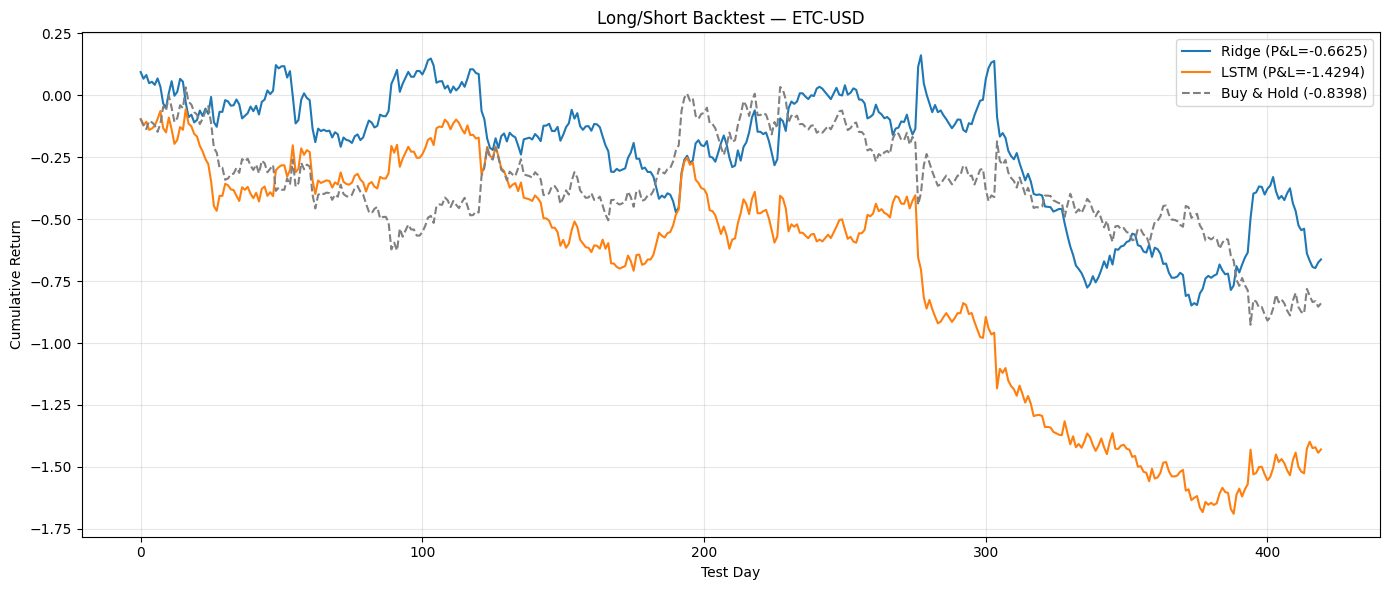

In [23]:
# Long/short backtest (Ridge + LSTM, v9)
def backtest_long_short(actual_ret, pred_ret, threshold=0.0, cost_bps=10):
    actual_ret = np.asarray(actual_ret).ravel()
    pred_ret = np.asarray(pred_ret).ravel()
    position = 0
    pnl_list = []
    cost = cost_bps / 10_000.0
    n_trades = 0
    for t in range(len(actual_ret)):
        signal = 1 if pred_ret[t] > threshold else (-1 if pred_ret[t] < -threshold else 0)
        trade_cost = cost if signal != position else 0.0
        position = signal
        n_trades += int(trade_cost > 0)
        pnl_list.append(position * actual_ret[t] - trade_cost)
    return np.array(pnl_list), n_trades

models_bt = [("Ridge", pred_ridge_test, y_test), ("LSTM", pred_lstm_test, y_te_lstm)]
plt.figure(figsize=(14, 6))
for name, preds, yt in models_bt:
    n_bt = min(len(preds), len(yt))
    pnl, nt = backtest_long_short(yt[-n_bt:], preds[-n_bt:], threshold=0.0, cost_bps=10)
    cum_pnl = np.cumsum(pnl)
    sharpe = np.mean(pnl) / (np.std(pnl) + 1e-10) * np.sqrt(252)
    print(f"{name:25s}: P&L={cum_pnl[-1]:+.4f}, Trades={nt}, Sharpe={sharpe:.2f}")
    plt.plot(cum_pnl, label=f"{name} (P&L={cum_pnl[-1]:+.4f})")
bh = np.cumsum(y_test)
plt.plot(bh, label=f"Buy & Hold ({bh[-1]:+.4f})", linestyle="--", color="gray")
plt.xlabel("Test Day"); plt.ylabel("Cumulative Return"); plt.title(f"Long/Short Backtest — {ASSET}")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 13. Summary (v9)

**v9** keeps a compact baseline pipeline: two baselines, Ridge (lag + volume + volatility), LSTM, 4-group ablation, permutation importance + PDP/ICE (Ridge), error analysis (residuals), expanding-window evaluation (Ridge). No XGBoost, ensemble, stacking, or classifier.

**Key findings:** See comparison table (Section 7), expanding-window (Section 8), ablation (Section 9), interpretability (Section 10), and error analysis (Section 11).


In [24]:
# Sanity checks (v9)
assert X_train.shape[1] == N_LAGS + len(EXTRA_FEATURE_COLS), f"Feature count mismatch: {X_train.shape[1]}"
assert not np.isnan(pred_ridge_test).any(), "NaN in Ridge predictions"
assert not np.isnan(pred_lstm_test).any(), "NaN in LSTM predictions"
print("All sanity checks passed.")


All sanity checks passed.


## 14. 7-Day Price Forecast

Using **Ridge** (the best-performing model, Sharpe 1.04) to iteratively forecast the next 7 trading days.
Each day's predicted return becomes `lag_1` for the next step. `log_volume` and `volatility_14` are carried forward from the last observed day.


In [ ]:
# ── 7-Day Iterative Price Forecast (Ridge) ───────────────────────────────────
# Ridge is the best model (Sharpe 1.04, +110.1% backtest P&L vs -27.5% buy-and-hold)
# Feature order: [lag_1, lag_2, ..., lag_30, log_volume, volatility_14]
# where lag_1 = most recent return. For steps 2-7, predicted returns fill the lag window.

# ── Last known state ─────────────────────────────────────────────────────────
last_price   = df["price"].iloc[-1]
last_date    = df.index[-1]
last_log_vol = float(df["log_volume"].iloc[-1])
last_vol14   = float(df["volatility_14"].iloc[-1])

# Seed the lag window with the last N_LAGS actual returns (index -1 = most recent)
window = df["ret"].values[-N_LAGS:].tolist()

# ── Iterative forecast ───────────────────────────────────────────────────────
forecast_dates   = []
forecast_returns = []
forecast_prices  = [last_price]
current_price    = last_price

for step in range(7):
    # Build feature vector: [lag_1, ..., lag_30, log_volume, volatility_14]
    lags = window[-N_LAGS:]          # [oldest ... newest], length 30
    x    = np.array(lags[::-1]       # flip -> [lag_1=newest, lag_2, ..., lag_30=oldest]
                    + [last_log_vol, last_vol14],
                    dtype=np.float64).reshape(1, -1)

    pred_ret   = float(best_ridge.predict(x)[0])
    next_price = current_price * (1.0 + pred_ret)

    # Advance calendar date, skip weekends
    next_date = last_date + pd.Timedelta(days=step + 1)
    while next_date.weekday() >= 5:
        next_date += pd.Timedelta(days=1)

    forecast_dates.append(next_date)
    forecast_returns.append(pred_ret)
    forecast_prices.append(next_price)

    # Roll the lag window: predicted return becomes the new lag_1 next iteration
    window.append(pred_ret)
    current_price = next_price

# ── Print table ──────────────────────────────────────────────────────────────
print(f"\n{'='*56}")
print(f"  7-Day Price Forecast — {ASSET}  (Ridge)")
print(f"{'='*56}")
print(f"  Last known date  : {last_date.date()}")
print(f"  Last known price : ${last_price:>12,.4f}")
print(f"{'─'*56}")
print(f"  {'Day':<5} {'Date':<14} {'Pred Δ':>10}  {'Pred Price':>14}")
print(f"{'─'*56}")
for i, (d, r, p) in enumerate(zip(forecast_dates, forecast_returns, forecast_prices[1:])):
    arrow = "▲" if r >= 0 else "▼"
    print(f"  +{i+1:<4} {str(d.date()):<14} {arrow}{abs(r)*100:>8.3f}%  ${p:>14,.4f}")
print(f"{'─'*56}")
total_chg = (forecast_prices[-1] / last_price - 1) * 100
print(f"  7-day total change: {total_chg:+.2f}%   →  ${forecast_prices[-1]:,.4f}")
print(f"{'='*56}")
print("\n  Note: volume and volatility are carried forward from the last observed day.")
print("  Uncertainty grows with each step as predicted returns feed into future lags.")

# ── Plot ─────────────────────────────────────────────────────────────────────
CONTEXT_DAYS = 30
ctx_prices = df["price"].iloc[-CONTEXT_DAYS:].values
ctx_dates  = df.index[-CONTEXT_DAYS:]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ctx_dates, ctx_prices,
        color="steelblue", linewidth=2,
        label=f"Actual (last {CONTEXT_DAYS} days)")
ax.plot([last_date] + forecast_dates, forecast_prices,
        color="darkorange", linestyle="--", marker="o", markersize=7, linewidth=2,
        label="Ridge forecast (next 7 days)")
ax.axvline(last_date, color="gray", linestyle=":", alpha=0.6, label="Forecast start")
ax.axvspan(last_date, forecast_dates[-1] + pd.Timedelta(days=1),
           alpha=0.07, color="darkorange")

for d, p in zip(forecast_dates, forecast_prices[1:]):
    ax.annotate(f"${p:,.0f}", xy=(d, p),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8, color="darkorange")

ax.set_title(f"7-Day Price Forecast — {ASSET}  (Ridge, best model)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Cross-Asset Comparison

Runs the full pipeline (baselines, Ridge, LSTM) for **BTC-USD, ETH-USD, XRP-USD, ETC-USD**.
Collects directional accuracy for each model × asset.


In [ ]:
# ── Cross-Asset Directional Accuracy Sweep ───────────────────────────────────
# Runs baselines + Ridge (Optuna) + LSTM for each asset.
# Collect dir.acc to update the cross-asset slide.

import warnings, gc
warnings.filterwarnings("ignore")

ASSETS = ["BTC-USD", "ETH-USD", "XRP-USD", "ETC-USD"]
N_OPTUNA_TRIALS = 20   # fewer trials for speed; increase if time allows
EPOCHS_MAX      = 30   # LSTM max epochs per asset (early stopping will cut it)

results = {}   # asset -> {model: dir_acc}

for ASSET_X in ASSETS:
    print(f"\n{'='*60}")
    print(f"  Running: {ASSET_X}")
    print(f"{'='*60}")

    # ── 1. Data ──────────────────────────────────────────────────
    raw_x = yf.download(ASSET_X, start="2017-01-01", end=None,
                        progress=False, auto_adjust=True)
    if isinstance(raw_x.columns, pd.MultiIndex):
        raw_x.columns = raw_x.columns.droplevel(1)
    raw_x.index = pd.to_datetime(raw_x.index).tz_localize(None)
    raw_x = raw_x.sort_index().ffill().dropna()

    df_x = pd.DataFrame(index=raw_x.index)
    df_x["price"]  = raw_x["Close"].values
    df_x["volume"] = raw_x["Volume"].values.astype(float)
    df_x["volume"] = df_x["volume"].fillna(0)
    df_x["ret"]    = (df_x["price"] - df_x["price"].shift(1)) / (df_x["price"].shift(1) + 1e-12)
    df_x["log_volume"]    = np.log1p(df_x["volume"])
    df_x["volatility_14"] = df_x["ret"].rolling(14).std()
    df_x = df_x.iloc[N_LAGS:].copy()
    df_x = df_x.replace([np.inf, -np.inf], np.nan).fillna(0)

    n_x       = len(df_x)
    tr_end_x  = int(TRAIN_FRAC * n_x)
    va_end_x  = int((TRAIN_FRAC + VAL_FRAC) * n_x)
    train_x   = df_x.iloc[:tr_end_x]
    val_x     = df_x.iloc[tr_end_x:va_end_x]
    test_x    = df_x.iloc[va_end_x:]
    print(f"  Train {len(train_x)} | Val {len(val_x)} | Test {len(test_x)}")

    # ── 2. Baselines ─────────────────────────────────────────────
    tp = test_x["price"].values
    m_lv = regression_metrics(tp[1:], tp[:-1])
    ma7  = pd.Series(tp).rolling(7).mean().values
    ok   = ~np.isnan(ma7[:-1])
    m_ma = regression_metrics(tp[1:][ok], ma7[:-1][ok])

    # ── 3. Ridge with Optuna ──────────────────────────────────────
    X_tr_x, y_tr_x, _     = build_return_lag_matrix(train_x, N_LAGS, EXTRA_FEATURE_COLS)
    X_va_x, y_va_x, _     = build_return_lag_matrix(val_x,   N_LAGS, EXTRA_FEATURE_COLS)
    X_te_x, y_te_x, pp_te_x = build_return_lag_matrix(test_x, N_LAGS, EXTRA_FEATURE_COLS)

    n_f_x  = X_tr_x.shape[1]
    tscv_x = TimeSeriesSplit(n_splits=5, gap=21)

    def ridge_obj_x(trial):
        alpha = trial.suggest_float("ridge__alpha", 1e-2, 1e2, log=True)
        pipe  = Pipeline([
            ("scale", ColumnTransformer(
                [("s", StandardScaler(), list(range(n_f_x)))],
                remainder="passthrough")),
            ("ridge", Ridge(alpha=alpha)),
        ])
        scores = []
        for tri, vai in tscv_x.split(X_tr_x):
            pipe.fit(X_tr_x[tri], y_tr_x[tri])
            scores.append(np.mean(np.abs(y_tr_x[vai] - pipe.predict(X_tr_x[vai]))))
        return float(np.mean(scores))

    opt_x = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    opt_x.optimize(ridge_obj_x, n_trials=N_OPTUNA_TRIALS)
    best_alpha_x = opt_x.best_params["ridge__alpha"]

    best_ridge_x = Pipeline([
        ("scale", ColumnTransformer(
            [("s", StandardScaler(), list(range(n_f_x)))],
            remainder="passthrough")),
        ("ridge", Ridge(alpha=best_alpha_x)),
    ])
    best_ridge_x.fit(np.vstack([X_tr_x, X_va_x]),
                     np.concatenate([y_tr_x, y_va_x]))
    pred_ridge_x = best_ridge_x.predict(X_te_x)
    da_ridge_x   = dir_acc_returns(y_te_x, pred_ridge_x)
    print(f"  Ridge alpha={best_alpha_x:.4f}  Dir.Acc={da_ridge_x:.4f}")

    # ── 4. LSTM ───────────────────────────────────────────────────
    X_tr_l, y_tr_l, _ = build_lstm_sequences(train_x, SEQ_LEN, LSTM_FEATURE_COLS)
    X_va_l, y_va_l, _ = build_lstm_sequences(val_x,   SEQ_LEN, LSTM_FEATURE_COLS)
    X_te_l, y_te_l, _ = build_lstm_sequences(test_x,  SEQ_LEN, LSTM_FEATURE_COLS)

    n_tr_l, sl_l, nf_l = X_tr_l.shape
    sc_l = StandardScaler()
    sc_l.fit(X_tr_l.reshape(-1, nf_l))
    Xtr_sc = sc_l.transform(X_tr_l.reshape(-1, nf_l)).reshape(n_tr_l,   sl_l, nf_l).astype(np.float32)
    Xva_sc = sc_l.transform(X_va_l.reshape(-1, nf_l)).reshape(X_va_l.shape[0], sl_l, nf_l).astype(np.float32)
    Xte_sc = sc_l.transform(X_te_l.reshape(-1, nf_l)).reshape(X_te_l.shape[0], sl_l, nf_l).astype(np.float32)

    tf.random.set_seed(RANDOM_STATE)
    m_lstm_x = tf.keras.Sequential([
        layers.Input(shape=(SEQ_LEN, len(LSTM_FEATURE_COLS))),
        layers.LSTM(64, return_sequences=True), layers.Dropout(0.2),
        layers.LSTM(32), layers.Dropout(0.2),
        layers.Dense(1),
    ])
    m_lstm_x.compile(optimizer="adam", loss="mse")
    m_lstm_x.fit(
        Xtr_sc, y_tr_l.astype(np.float32),
        validation_data=(Xva_sc, y_va_l.astype(np.float32)),
        epochs=EPOCHS_MAX, batch_size=32, verbose=0,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=10, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0),
        ]
    )
    pred_lstm_x = m_lstm_x.predict(Xte_sc, verbose=0).ravel()
    da_lstm_x   = dir_acc_returns(y_te_l, pred_lstm_x)
    print(f"  LSTM Dir.Acc={da_lstm_x:.4f}")

    results[ASSET_X] = {
        "Last Value": m_lv["dir_acc"],
        "7-Day MA":   m_ma["dir_acc"],
        "Lag+Ridge":  da_ridge_x,
        "LSTM":       da_lstm_x,
    }

    # Free GPU memory between assets
    del m_lstm_x; gc.collect()
    try: tf.keras.backend.clear_session()
    except: pass

# ── Print summary table ───────────────────────────────────────────────────────
print("\n" + "="*68)
print("  CROSS-ASSET DIRECTIONAL ACCURACY SUMMARY")
print("="*68)
header = f"  {'Asset':<12} {'Last Value':>11} {'7-Day MA':>10} {'Lag+Ridge':>11} {'LSTM':>8}"
print(header)
print("  " + "-"*62)
for asset, row in results.items():
    print(f"  {asset:<12} {row['Last Value']:>10.2%} {row['7-Day MA']:>10.2%} "
          f"{row['Lag+Ridge']:>10.2%} {row['LSTM']:>8.2%}")
print("="*68)
print("\nCopy these numbers into the cross-asset slide chart.")

